In [1]:
%reload_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import RectifiedFlow


In [3]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [4]:
import scipy


train_data = dataset["train"]   

def train_data_generator(batch_size=512):
    key = jax.random.key(0)
    while True:
        key,subkey, subkey2 = jax.random.split(key,3)
        idx = np.random.randint(0,len(train_data), size=batch_size)
        
        xs_batch = train_data[idx]["image"]/256
        #Rotate a bit
        xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform()*10, axes=(1,2), reshape=False)
        
        # Quantize
        xs_batch = jnp.array(train_data[idx]["image"]/256, dtype=jnp.float32).reshape(batch_size, 28,28,1)
        xs_batch += jax.random.uniform(subkey2, xs_batch.shape)/255 # Uniform dequantization
        # Rescale to [-1,1]
        xs_batch = 2*xs_batch - 1
        xs_batch = jnp.nan_to_num(xs_batch)
        
    
        
        yield xs_batch

datagenerator = train_data_generator()

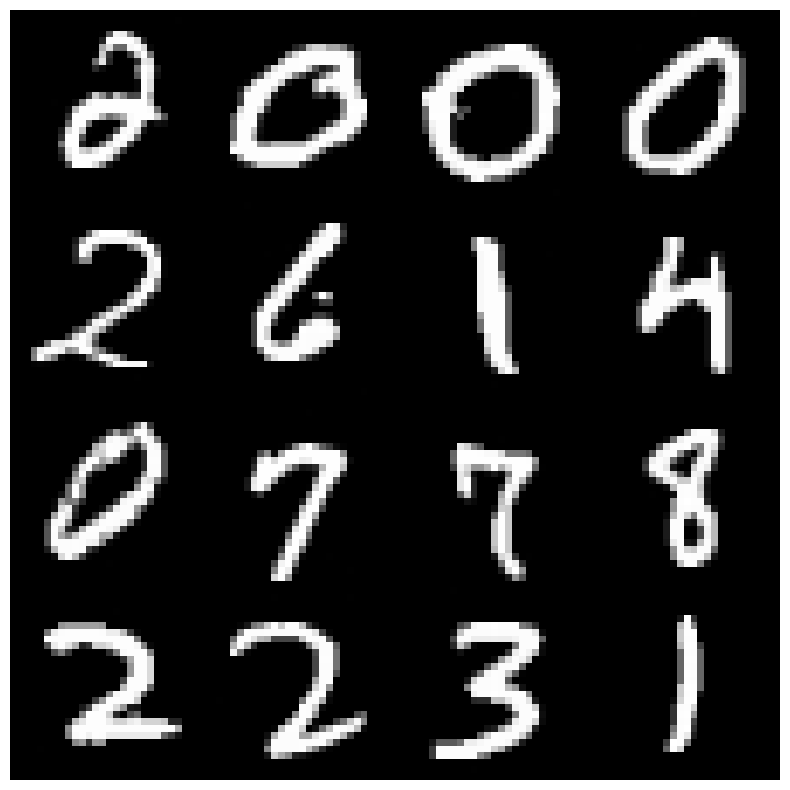

In [5]:
images = [next(datagenerator)[0, ..., 0] for _ in range(16)]
stacked_images = np.vstack([np.hstack(images[i*4:(i+1)*4]) for i in range(4)])

plt.figure(figsize=(10, 10))
plt.imshow(stacked_images, cmap="gray")
plt.axis('off')
plt.show()


In [6]:
from probjax.nn.nets.unets import UNet

In [18]:
d = 784
class Denoiser(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,128, rngs=rngs, learnable=True)
        self.net = UNet(1, rngs=rngs, kernel_size=(4,4), kernel_size_resnet=(3,3), out_features=[64, 128,256,512, 1024], context_features=128, use_attention=False, use_bias=True, num_groups=8)
        self.out_layer = nnx.Conv(1, 1,1, padding="SAME", kernel_init=nnx.initializers.zeros,use_bias=True, rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        out = self.net(x, context=time_embed)
        out = self.out_layer(out)
        return out

net = Denoiser(d, nnx.Rngs(1))
model = RectifiedFlow(net)
params = nnx.state(model, nnx.Param)

In [19]:
# Count parameters
print("Number of parameters: ", sum(np.prod(v.shape) for v in jax.tree_leaves(params)))

Number of parameters:  129860868


In [20]:
def loss_fn(params, x, rng):
    return model.loss(params, rng, x)


In [21]:
from functools import partial
import optax

schedule = optax.cosine_onecycle_schedule(50*200, 5e-4)
opt = optax.chain(optax.adaptive_grad_clip(20.), optax.ema(0.0001), optax.adamw(schedule))
params_per_device = jax.tree_util.tree_map(
    lambda p: jnp.stack([p] * jax.local_device_count(), axis=0), 
    params
)
opt_state = jax.vmap(opt.init)(params_per_device)

@partial(jax.pmap, axis_name='batch')
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    grads = jax.tree_map(lambda x: jnp.nan_to_num(x), grads)

    # Average across all replicas on the 'batch' axis
    loss = jax.lax.pmean(loss, axis_name='batch')
    grads = jax.lax.pmean(grads, axis_name='batch')

    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    params = jax.tree_map(lambda x: jnp.nan_to_num(x), params)
    return params, opt_state, loss

def train_step(params, opt_state, xs, rng):
    rngs = jax.random.split(rng, jax.local_device_count())

    # Reshape xs to split across devices
    xs_split = jnp.reshape(xs, (jax.local_device_count(), -1, *xs.shape[1:]))

    params, opt_state, losses = update(params, opt_state, xs_split, rngs)
    return params, opt_state, jnp.mean(losses)


In [62]:
key = jax.random.key(2)

In [63]:
# Example training iteration
for i in range(50):
    l = 0.
    for j in range(200): 
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datagenerator)
        params_per_device, opt_state, loss = train_step(params_per_device, opt_state, xs, key_loss)
        l += loss
    print(l/200)

1272.7852
1261.3378
1272.5717
1270.0359
1275.848
1275.727
1279.0452
1254.9617
1240.8876
1283.8673
1261.332
1265.9901
1267.5684
1273.2559
1302.0825
1267.0338


KeyboardInterrupt: 

In [24]:
params = jax.tree_map(lambda x: x[0], params_per_device)
nnx.update(model, params)

(28, 28, 64)
(14, 14, 128)
(7, 7, 256)
(4, 4, 512)
(2, 2, 1024)


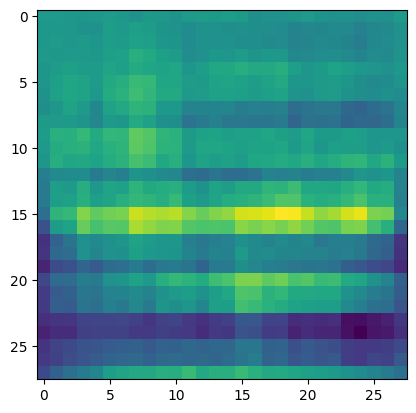

In [61]:
plt.imshow(model(jnp.zeros((1,)) + 0.01, jax.random.normal(key, (28,28,1,)))[...,0])

In [42]:
from probjax.utils.odeint import odeint



def sample(rng):
    eps = jax.random.normal(rng, (28,28,1,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(50) 

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x) # Why is this negative?
        return v.reshape(x.shape)

    return odeint(drift, eps,ts, method="euler")



In [43]:
keys = jax.random.split(jax.random.key(0), (16,))

In [44]:
xs = jax.vmap(sample)(keys)

(28, 28, 64)
(14, 14, 128)
(7, 7, 256)
(4, 4, 512)
(2, 2, 1024)


In [47]:
x = sample(jax.random.key(0))

(28, 28, 64)
(14, 14, 128)
(7, 7, 256)
(4, 4, 512)
(2, 2, 1024)


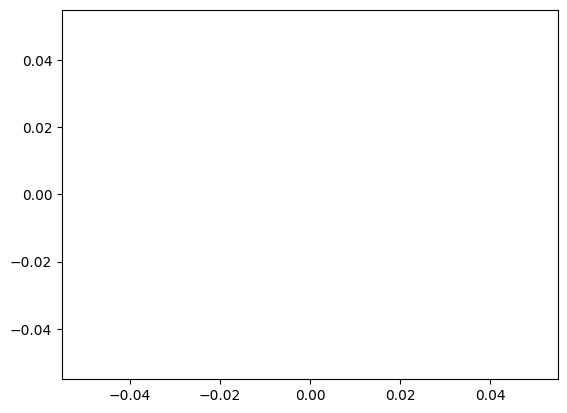

In [49]:
plt.plot(x[:, 0,0])

In [46]:
xs.max(), xs.min()

(Array(nan, dtype=float32), Array(nan, dtype=float32))

In [32]:
import matplotlib.pyplot as plt

img = xs.reshape(4, 4, 28, 28).transpose(0, 2, 1, 3).reshape(4*28, 4*28)
plt.imshow(img, cmap="gray", vmin=0, vmax=1.)

TypeError: cannot reshape array of shape (16, 50, 28, 28, 1) (size 627200) into shape (4, 4, 28, 28) (size 12544)